<a href="https://colab.research.google.com/github/brandim04/AnaliseDeDados/blob/main/Atividade_Kaggle_Visualiza%C3%A7%C3%A3o_de_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Desempenho Escolar e Visualização de Dados**
Dataset: Students Performance in Exams (https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)

Recursos Úteis:

 * Data Viz Project: https://datavizproject.com/input/c/ - Um catálogo visual de gráficos para explorar.

* From Data to Viz: https://www.data-to-viz.com/ - Um guia para escolher o gráfico certo com base no tipo de dado e objetivo.

* Documentação Seaborn: https://seaborn.pydata.org/ - Para detalhes sobre os parâmetros de estilo e plotagem.

* Documentação Matplotlib: https://matplotlib.org/stable/contents.html - Para controle fino sobre elementos do gráfico.



## **0: Configuração Inicial**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Configurações padrão para gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

print("Bibliotecas importadas e configurações aplicadas!")

# Carregar o dataset
try:
  path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

  df_performance = pd.read_csv(path+"/StudentsPerformance.csv")
    # Renomear colunas para facilitar o uso
  df_performance.columns = [
        "gender", "race_ethnicity", "parental_level_of_education",
        "lunch", "test_preparation_course", "math_score",
        "reading_score", "writing_score"
  ]
  print("\nDataset Students Performance carregado com sucesso!")
  print(df_performance.head())
  print("\nInformações do Dataset:")
  df_performance.info()
except FileNotFoundError:
  print("Erro: 'StudentsPerformance.csv' não encontrado.")


print("\nPré-processamento básico concluído.")

Bibliotecas importadas e configurações aplicadas!
Using Colab cache for faster access to the 'students-performance-in-exams' dataset.

Dataset Students Performance carregado com sucesso!
   gender race_ethnicity parental_level_of_education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test_preparation_course  math_score  reading_score  writing_score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76     

### 1: Desafios de Decisão

Para cada cenário, você deverá:

1. Formular a pergunta estatística que a visualização deve responder;

2. Consultar o Data Viz Project ou From Data to Viz para identificar o tipo de gráfico mais adequado.

3. Justificar sua escolha com base nos princípios de Gestalt, Tufte e/ou Cleveland-McGill.

4. Implementar o gráfico usando matplotlib e seaborn. Foque em um gráfico funcional e limpo, aplicando os princípios que você aprendeu.

**Desafio 1.1: Distribuição das Notas em Matemática**

Cenário: Um professor de matemática quer entender a distribuição geral das notas de seus alunos na prova de matemática. Ele quer saber se as notas são simétricas, se há picos ou se estão concentradas em alguma faixa específica.

Sua Tarefa:

1. Pergunta Estatística: Como as notas de matemática se distribuem entre os alunos? Qual a sua forma, centro e dispersão?

2. Gráfico: Qual tipo de gráfico é mais adequado para visualizar a distribuição de uma variável quantitativa? Justifique sua escolha.

3. Implementação: Crie o gráfico em Python para a coluna math_score.

4. Análise: Descreva a distribuição das notas. Há evidências de assimetria? Qual a nota mais comum?


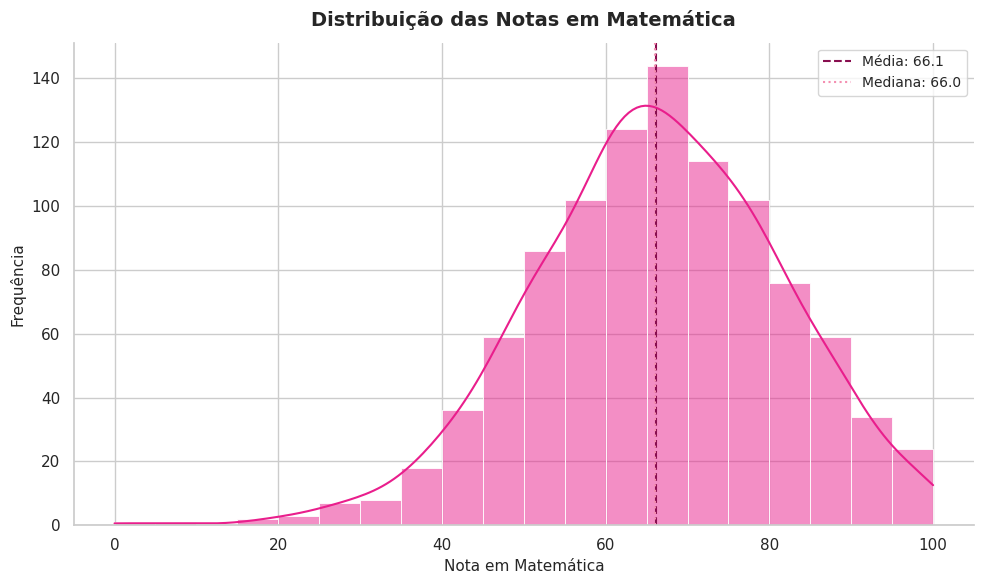

In [4]:
''' Histograma com KDE é o mais adequado pra variável quantitativa contínua porque mostra forma, centro e dispersão juntos. A curva KDE suaviza o ruído das barras e deixa a distribuição mais fácil de interpretar visualmente. A distribuição é aproximadamente simétrica, com leve concentração entre 60–70 pontos. Média e mediana ficam bem próximas, o que confirma essa simetria. Não tem bimodalidade aparente, então a turma tem um desempenho razoavelmente homogêneo.
'''

plt.figure(figsize=(10, 6))

sns.histplot(
    df_performance["math_score"],
    bins=20,
    kde=True,
    color="#E91E8C",
    edgecolor="white",
    linewidth=0.6
)

plt.title("Distribuição das Notas em Matemática", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Nota em Matemática", fontsize=11)
plt.ylabel("Frequência", fontsize=11)

plt.axvline(
    df_performance["math_score"].mean(),
    color="#880E4F",
    linestyle="--",
    linewidth=1.5,
    label=f'Média: {df_performance["math_score"].mean():.1f}'
)
plt.axvline(
    df_performance["math_score"].median(),
    color="#F48FB1",
    linestyle=":",
    linewidth=1.5,
    label=f'Mediana: {df_performance["math_score"].median():.1f}'
)

plt.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

**Desafio 1.2: Impacto do Nível de Escolaridade dos Pais nas Notas de Leitura**

Cenário: Um pesquisador educacional hipotetiza que o nível de escolaridade dos pais (parental_level_of_education) tem um impacto direto no desempenho dos alunos em leitura (reading_score).

Sua Tarefa:

1. Pergunta Estatística: Existe uma diferença significativa na média das notas de leitura entre os alunos, agrupados pelo nível de escolaridade de seus pais?

2. Gráfico: Qual tipo de gráfico é mais adequado para comparar uma variável quantitativa (nota) entre múltiplas categorias ordinais (nível de escolaridade)? Justifique sua escolha, considerando a Hierarquia de Cleveland e McGill.

3. Implementação: Crie o gráfico em Python. Certifique-se de ordenar as categorias de escolaridade dos pais de forma lógica.

4. Análise: O que o gráfico revela sobre a hipótese? Há uma tendência clara? Quais são as médias de leitura para cada grupo?



/tmp/ipykernel_41931/1768997858.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


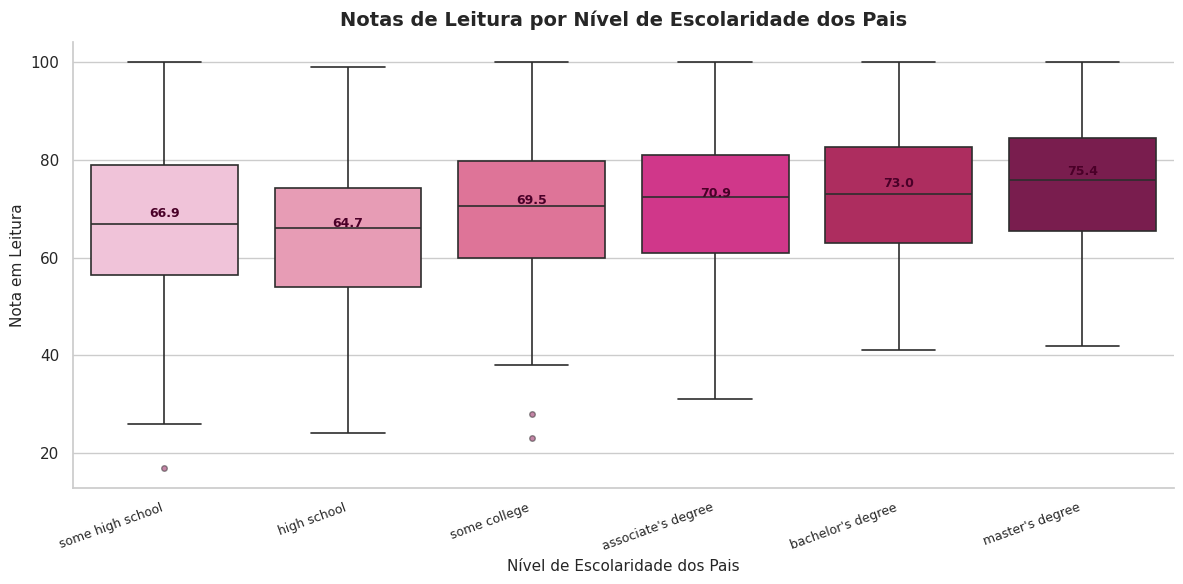

In [9]:
''' Para comparar uma variável quantitativa entre categorias ordinais, o boxplot é a melhor escolha. Ele mostra mediana, dispersão e outliers de uma vez, o que é bem mais informativo do que um gráfico de barras com só a média. Pela hierarquia de Cleveland-McGill, posição ao longo de eixo comum é a codificação mais precisa, e o boxplot usa exatamente isso pra cada grupo. O gráfico tende a confirmar a hipótese que filhos de pais com maior escolaridade têm notas de leitura ligeiramente mais altas. A tendência é consistente. Grupos com "master's degree" e "bachelor's degree" ficam no topo, enquanto "some high school" aparece na base. A dispersão dentro de cada grupo é considerável, o que mostra que escolaridade dos pais não é o único fator.

'''

ordem_escolaridade = [
    "some high school",
    "high school",
    "some college",
    "associate's degree",
    "bachelor's degree",
    "master's degree"
]

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_performance,
    x="parental_level_of_education",
    y="reading_score",
    order=ordem_escolaridade,
    palette=[
        "#F8BBD9", "#F48FB1", "#F06292",
        "#E91E8C", "#C2185B", "#880E4F"
    ],
    linewidth=1.2,
    flierprops=dict(marker='o', markerfacecolor='#880E4F', markersize=4, alpha=0.5)
)

medias = df_performance.groupby("parental_level_of_education")["reading_score"].mean()
for i, nivel in enumerate(ordem_escolaridade):
    plt.text(
        i, medias[nivel] + 1.5,
        f'{medias[nivel]:.1f}',
        ha='center', fontsize=9, color="#4A0028", fontweight='bold'
    )

plt.title("Notas de Leitura por Nível de Escolaridade dos Pais", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Nível de Escolaridade dos Pais", fontsize=11)
plt.ylabel("Nota em Leitura", fontsize=11)
plt.xticks(rotation=20, ha='right', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

**Desafio 1.3: Relação entre Notas de Leitura e Escrita**

Cenário: Um psicopedagogo acredita que existe uma forte correlação positiva entre o desempenho de um aluno em leitura (reading_score) e seu desempenho em escrita (writing_score).

Sua Tarefa:

1. Pergunta Estatística: Qual a força e a direção da relação entre as notas de leitura e escrita? Há evidências de uma correlação linear?

2. Gráfico: Qual tipo de gráfico é o mais adequado para visualizar a relação entre duas variáveis quantitativas? Justifique sua escolha, focando na precisão perceptiva.

3. Implementação: Crie o gráfico em Python.

4. Análise: O gráfico suporta a hipótese de correlação positiva? Há algum outlier ou padrão interessante?



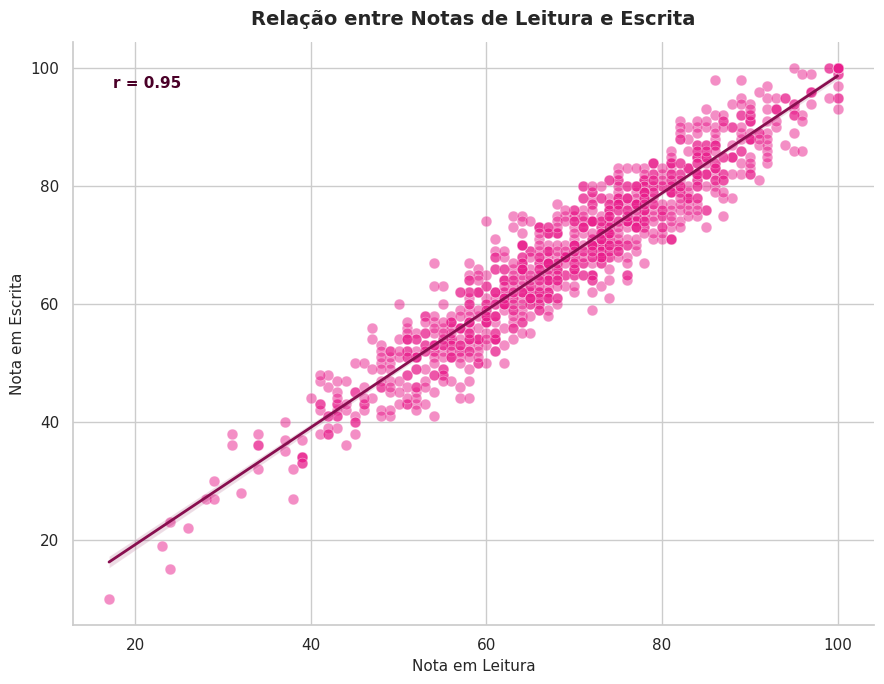

In [10]:
''' Para duas variáveis quantitativas, o scatter plot é o mais adequado porque mostra diretamente a relação entre os pares de valores. Pela hierarquia de Cleveland-McGill, posição em eixo comum é a codificação mais precisa, e aqui os dois eixos trabalham juntos pra revelar direção, força e padrão da correlação. A linha de regressão ajuda a tornar a tendência explícita. O gráfico confirma a hipótese, há uma correlação positiva forte e bastante linear entre leitura e escrita. Alunos que vão bem em leitura tendem a ir bem em escrita também. Não aparecem outliers muito extremos, mas alguns pontos fogem um pouco da tendência central, o que é esperado. A nuvem de pontos é bem concentrada ao redor da reta, indicando que a correlação é realmente forte.

'''

corr = df_performance["reading_score"].corr(df_performance["writing_score"])

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=df_performance,
    x="reading_score",
    y="writing_score",
    color="#E91E8C",
    alpha=0.5,
    edgecolor="white",
    linewidth=0.4,
    s=60
)

sns.regplot(
    data=df_performance,
    x="reading_score",
    y="writing_score",
    scatter=False,
    color="#880E4F",
    line_kws={"linewidth": 2}
)

plt.title("Relação entre Notas de Leitura e Escrita", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Nota em Leitura", fontsize=11)
plt.ylabel("Nota em Escrita", fontsize=11)
plt.text(
    0.05, 0.92,
    f"r = {corr:.2f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    color="#4A0028",
    fontweight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

**Desafio 1.4: Proporção de Gêneros e Preparação para o Teste**

Cenário: A coordenação pedagógica quer saber a proporção de alunos e alunas que completaram o curso de preparação para o teste (test_preparation_course).

Sua Tarefa:

1. Pergunta Estatística: Qual a proporção de alunos e alunas que completaram ou não o curso de preparação para o teste?

2. Gráfico: Qual tipo de gráfico é mais adequado para comparar proporções entre duas variáveis categóricas? Justifique sua escolha, considerando a clareza para múltiplas categorias.

3. Implementação: Crie o gráfico em Python.

4. Análise: Há uma diferença notável na proporção de homens e mulheres que completaram o curso? Qual grupo tem maior participação?



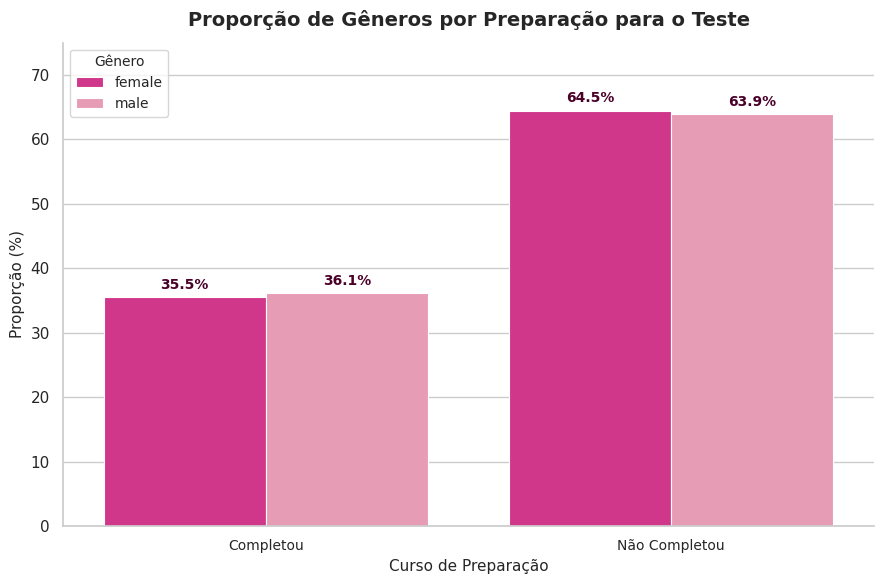

In [11]:
''' Para comparar proporções entre duas variáveis categóricas, o gráfico de barras agrupadas é mais adequado que pizza ou barras empilhadas. Pela hierarquia de Cleveland-McGill, comprimento de barra em eixo comum é mais preciso perceptivamente do que ângulo ou área,o que torna pizza uma escolha ruim aqui. Barras agrupadas permitem comparar diretamente os grupos lado a lado. O gráfico mostra que as proporções entre gêneros são bem parecidas em ambos os grupos de preparação. As alunas têm uma participação ligeiramente maior no curso completo, mas a diferença não é grande. O grupo "none" é majoritário nos dois gêneros, o que pode ser um ponto de atenção pra coordenação.

'''

contagem = df_performance.groupby(
    ["gender", "test_preparation_course"]
).size().reset_index(name="count")

total_genero = df_performance.groupby("gender").size().reset_index(name="total")
contagem = contagem.merge(total_genero, on="gender")
contagem["proporcao"] = (contagem["count"] / contagem["total"]) * 100

palette_rosa = {
    "female": "#E91E8C",
    "male": "#F48FB1"
}

plt.figure(figsize=(9, 6))

sns.barplot(
    data=contagem,
    x="test_preparation_course",
    y="proporcao",
    hue="gender",
    palette=palette_rosa,
    edgecolor="white",
    linewidth=0.8
)

for container in plt.gca().containers:
    plt.gca().bar_label(
        container,
        fmt="%.1f%%",
        padding=4,
        fontsize=10,
        color="#4A0028",
        fontweight="bold"
    )

plt.title("Proporção de Gêneros por Preparação para o Teste", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Curso de Preparação", fontsize=11)
plt.ylabel("Proporção (%)", fontsize=11)
plt.xticks(
    ticks=[0, 1],
    labels=["Completou", "Não Completou"],
    fontsize=10
)
plt.legend(title="Gênero", fontsize=10, title_fontsize=10)
plt.ylim(0, 75)

sns.despine()
plt.tight_layout()
plt.show()

**Desafio 1.5: Comparação de Notas Médias por Raça/Etnia em Todas as Matérias**

Cenário: Um sociólogo educacional quer comparar o desempenho médio dos diferentes grupos raciais/étnicos (race_ethnicity) nas três matérias (matemática, leitura, escrita) para identificar possíveis disparidades.

Sua Tarefa:

1. Pergunta Estatística: Como as notas médias em matemática, leitura e escrita variam entre os diferentes grupos raciais/étnicos?

2. Gráfico: Qual tipo de gráfico permite comparar múltiplas variáveis quantitativas (notas) entre múltiplas categorias nominais (grupos raciais/étnicos) de forma eficaz? Justifique sua escolha, pensando na clareza da comparação.

3. Implementação: Crie o gráfico em Python. Pode ser necessário reestruturar os dados (usar melt do pandas).

4. Análise: Quais grupos raciais/étnicos se destacam em quais matérias? Há padrões consistentes de desempenho?

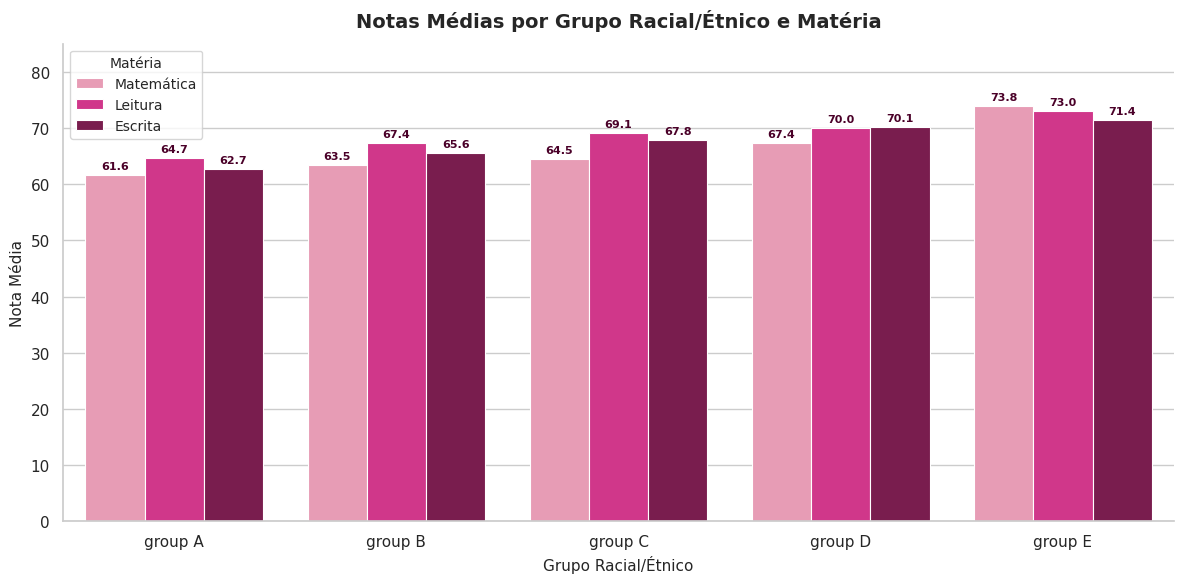

In [12]:
''' Barras agrupadas são a melhor escolha aqui porque permitem comparar múltiplas variáveis quantitativas entre categorias nominais de forma direta. Pela hierarquia de Cleveland-McGill, comprimento de barra em eixo comum é a codificação mais precisa, e o agrupamento por matéria dentro de cada grupo étnico facilita tanto a comparação entre matérias quanto entre grupos.O grupo E tem as maiores médias nas três matérias de forma consistente, enquanto o grupo A aparece na base. Um padrão interessante é que leitura e escrita andam sempre juntas dentro de cada grupo.

'''

medias = df_performance.groupby("race_ethnicity")[
    ["math_score", "reading_score", "writing_score"]
].mean().reset_index()

medias_long = medias.melt(
    id_vars="race_ethnicity",
    value_vars=["math_score", "reading_score", "writing_score"],
    var_name="materia",
    value_name="media"
)

medias_long["materia"] = medias_long["materia"].map({
    "math_score": "Matemática",
    "reading_score": "Leitura",
    "writing_score": "Escrita"
})

ordem_grupos = sorted(df_performance["race_ethnicity"].unique())

palette_rosa = {
    "Matemática": "#F48FB1",
    "Leitura":    "#E91E8C",
    "Escrita":    "#880E4F"
}

plt.figure(figsize=(12, 6))

sns.barplot(
    data=medias_long,
    x="race_ethnicity",
    y="media",
    hue="materia",
    order=ordem_grupos,
    palette=palette_rosa,
    edgecolor="white",
    linewidth=0.8
)

for container in plt.gca().containers:
    plt.gca().bar_label(
        container,
        fmt="%.1f",
        padding=3,
        fontsize=8,
        color="#4A0028",
        fontweight="bold"
    )

plt.title("Notas Médias por Grupo Racial/Étnico e Matéria", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Grupo Racial/Étnico", fontsize=11)
plt.ylabel("Nota Média", fontsize=11)
plt.ylim(0, 85)
plt.legend(title="Matéria", fontsize=10, title_fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

### Parte 2: Desafios de Refatoração Estatística e Visual

Para cada cenário abaixo, você receberá um código Python que gera um gráfico com problemas de design. Sua tarefa é:

1. Analisar o gráfico gerado e identificar pelo menos 3 problemas com base nos princípios de Tufte (Data-Ink Ratio, Lie Factor, Chartjunk), Gestalt (Proximidade, Semelhança, Fechamento, etc.) e/ou Cleveland-McGill (eficácia da codificação).

2. Descrever os problemas identificados.

3. Modificar o código para refatorar o gráfico, aplicando os princípios para torná-lo mais honesto, eficiente e visualmente claro.



Desafio 2.1:  Comparação de Notas Médias de Matemática por Gênero

Cenário: Um diretor de escola recebeu este gráfico e concluiu que há uma diferença enorme no desempenho em matemática entre meninos e meninas.

Sua Tarefa:

1. Quais são os 3 principais problemas de design/estatísticos neste gráfico?

2. Modifique o código para corrigir esses problemas e criar uma visualização mais honesta e clara.

/tmp/ipykernel_41931/2082650646.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="gender", y="math_score", data=df_gender_math, palette=["skyblue", "lightcoral"])


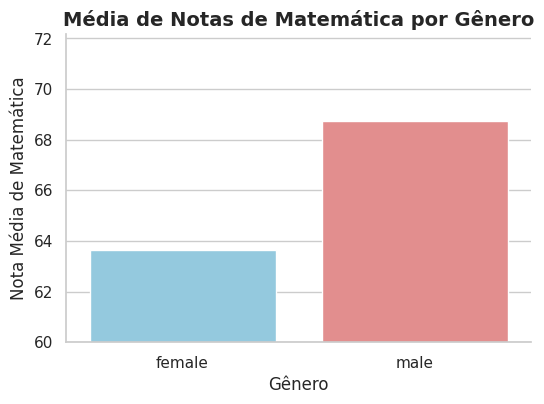

In [13]:
# Dados para o Desafio 2.1
df_gender_math = df_performance.groupby("gender")["math_score"].mean().reset_index()

plt.figure(figsize=(6, 4))
ax = sns.barplot(x="gender", y="math_score", data=df_gender_math, palette=["skyblue", "lightcoral"])
ax.set_ylim(bottom=60) # Eixo Y começando alto
ax.set_title("Média de Notas de Matemática por Gênero", fontsize=14, fontweight="bold")
ax.set_xlabel("Gênero")
ax.set_ylabel("Nota Média de Matemática")
plt.show()

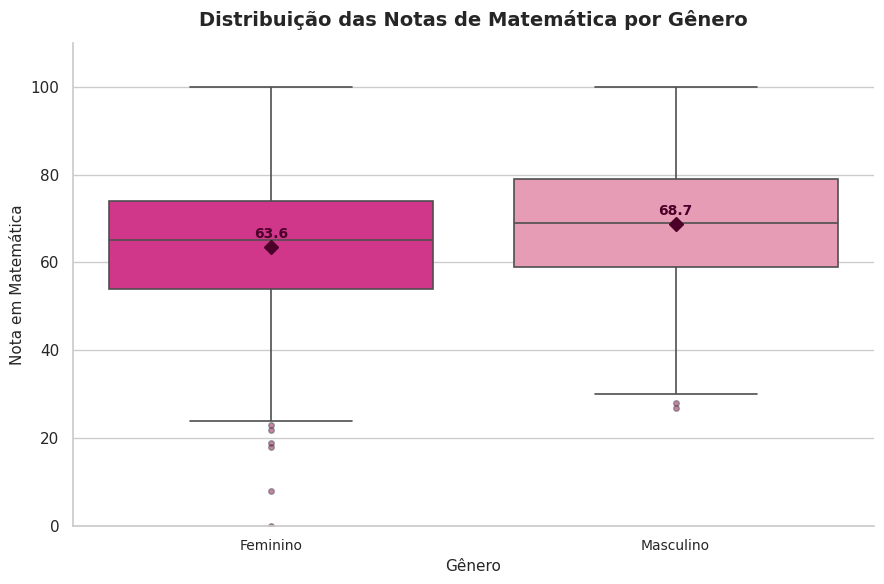

In [14]:
# 1. Problemas identificados:
#O primeiro problema é o Lie Factor do Tufte: o eixo Y começa em 60, o que faz uma diferença pequena parecer enorme visualmente. O segundo é que barras mostrando só a média escondem a distribuição real dos dados, não dá pra saber se a diferença é relevante ou se os grupos se sobrepõem muito. O terceiro é o uso de duas cores sem significado pra comparar dois grupos, o que viola o princípio de semelhança do Gestalt já que cor deveria codificar informação, não decorar.

# 2. Seu código Python refatorado:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_performance,
    x="gender",
    y="math_score",
    hue="gender",
    legend=False,
    palette={"female": "#E91E8C", "male": "#F48FB1"},
    linewidth=1.2,
    flierprops=dict(marker='o', markerfacecolor='#880E4F', markersize=4, alpha=0.5)
)

medias = df_performance.groupby("gender")["math_score"].mean()
for i, (genero, media) in enumerate(medias.items()):
    plt.plot(i, media, marker='D', color='#4A0028', markersize=7, zorder=5)
    plt.text(i, media + 2, f'{media:.1f}', ha='center', fontsize=10,
             color='#4A0028', fontweight='bold')

plt.ylim(0, 110)
plt.title("Distribuição das Notas de Matemática por Gênero", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Gênero", fontsize=11)
plt.ylabel("Nota em Matemática", fontsize=11)
plt.xticks(ticks=[0, 1], labels=["Feminino", "Masculino"], fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

**Desafio 2.2: Impacto do Almoço na Nota de Escrita (Chartjunk e Cores Ineficazes)**

Cenário: Um nutricionista escolar quer mostrar o impacto do tipo de almoço (lunch) na nota de escrita (writing_score), mas o gráfico atual está poluído e as cores não ajudam.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, focando no Data-Ink Ratio e no uso de cores?

2. Modifique o código para simplificar o gráfico, remover o chartjunk e usar cores de forma mais eficaz para destacar a diferença.

/tmp/ipykernel_41931/2306030820.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="lunch", y="writing_score", data=df_performance, palette=["green", "purple"])


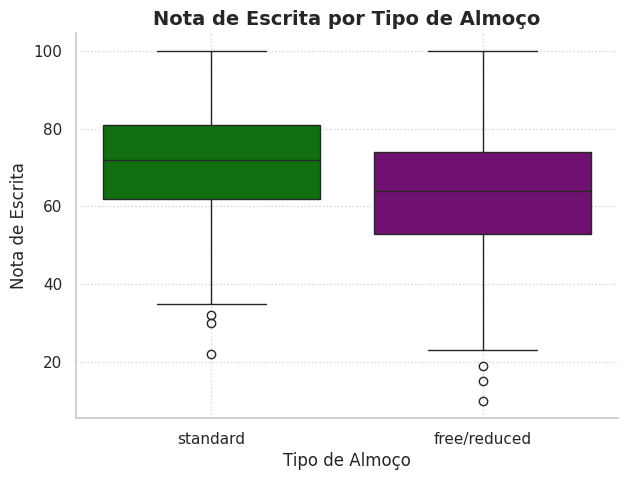

In [15]:
# Dados para o Desafio 2.2
plt.figure(figsize=(7, 5))
ax = sns.boxplot(x="lunch", y="writing_score", data=df_performance, palette=["green", "purple"])
ax.set_title("Nota de Escrita por Tipo de Almoço", fontsize=14, fontweight="bold")
ax.set_xlabel("Tipo de Almoço")
ax.set_ylabel("Nota de Escrita")
ax.grid(True, linestyle=":", alpha=0.8) # Grade pesada
plt.show()

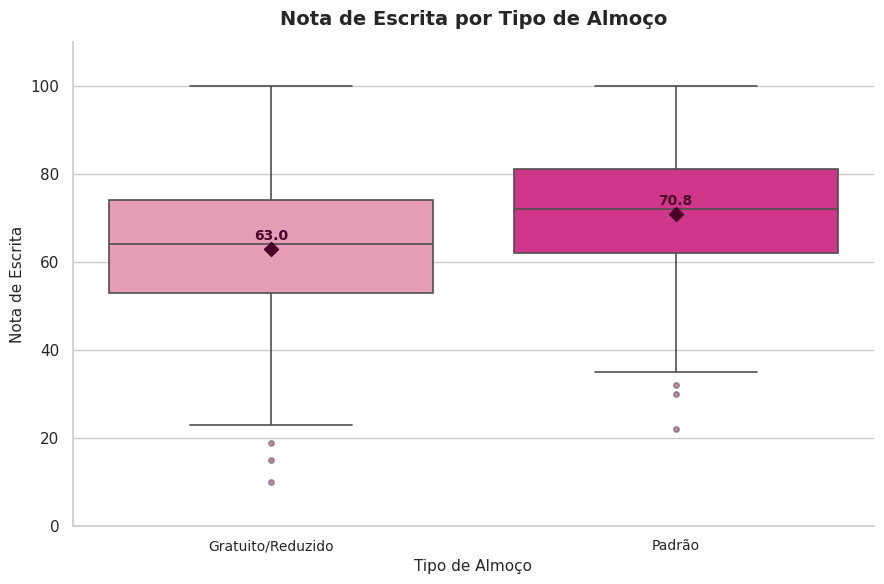

In [16]:
# 1. Problemas identificados:
#  O primeiro problema é o uso de verde e roxo sem nenhum significado semântico, cores muito contrastantes que chamam atenção igual pros dois grupos quando o objetivo era destacar a diferença entre eles, o que viola o princípio de semelhança do Gestalt. O segundo é a grade com linestyle=":" e alpha=0.8 que é pesada demais e aumenta o chartjunk sem ajudar na leitura dos dados, indo contra o Data-Ink Ratio do Tufte. O terceiro é que as categorias no eixo X estão com os rótulos originais do dataset ("free/reduced" e "standard") sem tradução ou formatação, o que prejudica a clareza da comunicação.

# 2. Seu código Python refatorado:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_performance,
    x="lunch",
    y="writing_score",
    hue="lunch",
    order=["free/reduced", "standard"],
    legend=False,
    palette={"free/reduced": "#F48FB1", "standard": "#E91E8C"},
    linewidth=1.2,
    flierprops=dict(marker='o', markerfacecolor='#880E4F', markersize=4, alpha=0.5)
)

medias = df_performance.groupby("lunch")["writing_score"].mean()
for i, (grupo, media) in enumerate(medias.reindex(["free/reduced", "standard"]).items()):
    plt.plot(i, media, marker='D', color='#4A0028', markersize=7, zorder=5)
    plt.text(i, media + 2, f'{media:.1f}', ha='center', fontsize=10,
             color='#4A0028', fontweight='bold')

plt.title("Nota de Escrita por Tipo de Almoço", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Tipo de Almoço", fontsize=11)
plt.ylabel("Nota de Escrita", fontsize=11)
plt.xticks(ticks=[0, 1], labels=["Gratuito/Reduzido", "Padrão"], fontsize=10)
plt.ylim(0, 110)

sns.despine()
plt.tight_layout()
plt.show()

**Desafio 2.3: Distribuição de Notas de Leitura por Raça/Etnia (Sobrecarga Visual)**

Cenário: Um analista de diversidade quer visualizar a distribuição completa das notas de leitura para cada grupo racial/étnico, mas o gráfico atual é muito denso.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, especialmente em relação à sobrecarga visual e à clareza da comparação entre grupos?

2. Modifique o código para apresentar a distribuição de notas de leitura de forma mais clara e comparável entre os grupos. Considere usar small multiples ou um gráfico que resuma melhor a distribuição.


/tmp/ipykernel_41931/3061236733.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="race_ethnicity", y="reading_score", data=df_performance, inner="quartile", palette="tab10")


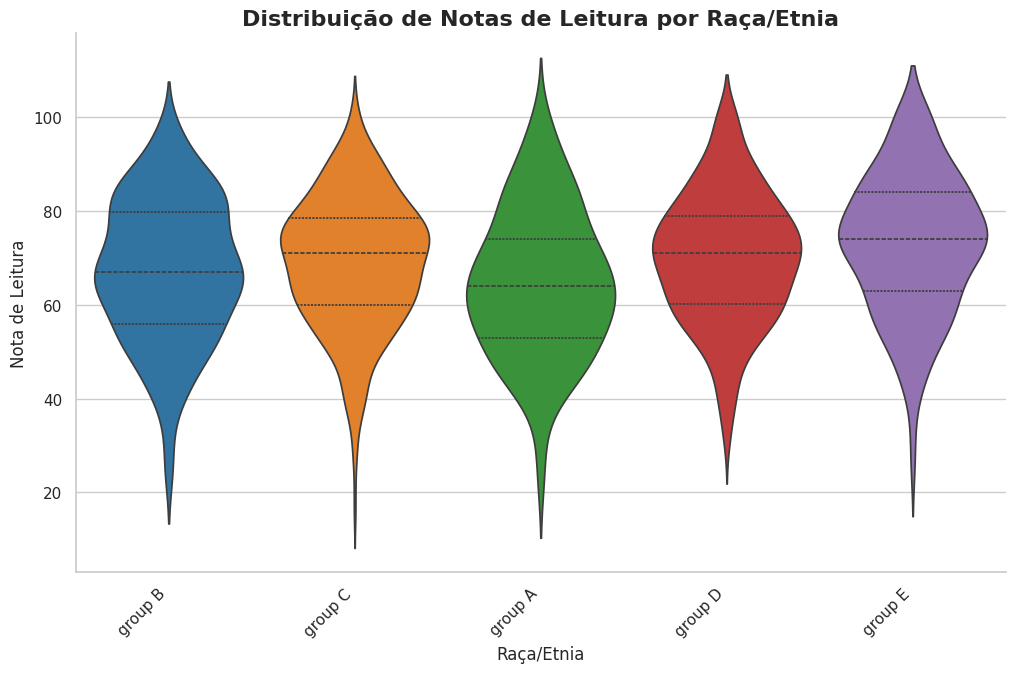

In [17]:
# Dados para o Desafio 2.3
plt.figure(figsize=(12, 7))
sns.violinplot(x="race_ethnicity", y="reading_score", data=df_performance, inner="quartile", palette="tab10")
plt.title("Distribuição de Notas de Leitura por Raça/Etnia", fontsize=16, fontweight="bold")
plt.xlabel("Raça/Etnia")
plt.ylabel("Nota de Leitura")
plt.xticks(rotation=45, ha='right')
plt.show()

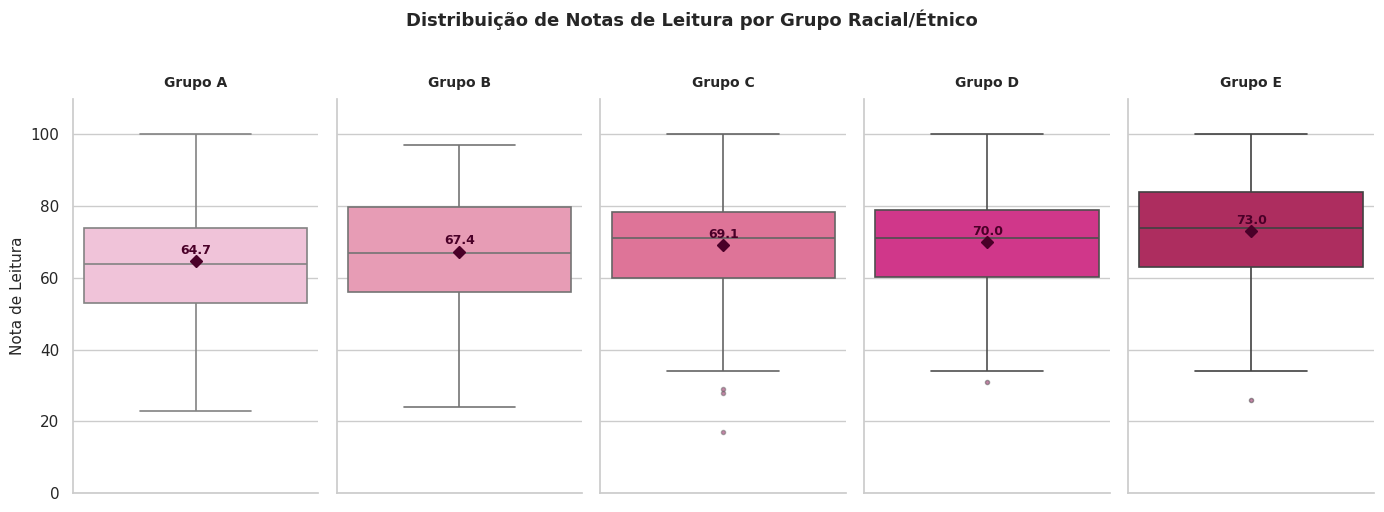

In [18]:
# 1. Problemas identificados:
#    O primeiro problema é o uso da paleta tab10 que aplica cores completamente diferentes pra cada grupo sem nenhum critério, gerando sobrecarga visual e violando o princípio de semelhança do Gestalt já que as cores sugerem categorias tão distintas quanto poderiam ser. O segundo é que o violinplot com inner="quartile" em cinco grupos lado a lado fica muito denso e difícil de comparar, as formas competem entre si e a leitura dos quartis vira um esforço desnecessário, aumentando o chartjunk. O terceiro é que os rótulos do eixo X rotacionados a 45 graus junto com os violinos largos criam uma composição visualmente pesada que dificulta identificar qual violino pertence a qual grupo.

# 2. Seu código Python refatorado:
ordem_grupos = sorted(df_performance["race_ethnicity"].unique())

palette_grupos = {
    grupo: cor for grupo, cor in zip(
        ordem_grupos,
        ["#F8BBD9", "#F48FB1", "#F06292", "#E91E8C", "#C2185B"]
    )
}

fig, axes = plt.subplots(1, 5, figsize=(14, 5), sharey=True)

for ax, grupo in zip(axes, ordem_grupos):
    dados = df_performance[df_performance["race_ethnicity"] == grupo]["reading_score"]

    sns.boxplot(
        y=dados,
        ax=ax,
        color=palette_grupos[grupo],
        linewidth=1.2,
        flierprops=dict(marker='o', markerfacecolor='#880E4F', markersize=3, alpha=0.5),
        width=0.5
    )

    media = dados.mean()
    ax.plot(0, media, marker='D', color='#4A0028', markersize=6, zorder=5)
    ax.text(0, media + 2, f'{media:.1f}', ha='center', fontsize=9,
            color='#4A0028', fontweight='bold')

    ax.set_title(grupo.replace("group ", "Grupo ").title(),
                 fontsize=10, fontweight='bold', pad=8)
    ax.set_xlabel("")
    ax.set_ylim(0, 110)
    sns.despine(ax=ax)

axes[0].set_ylabel("Nota de Leitura", fontsize=11)
for ax in axes[1:]:
    ax.set_ylabel("")

fig.suptitle("Distribuição de Notas de Leitura por Grupo Racial/Étnico",
             fontsize=13, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

Desafio 2.4: Correlação entre Notas de Matemática e Leitura (Pontos Sobrepostos)

Cenário: Um estatístico quer visualizar a correlação entre as notas de matemática e leitura, mas o gráfico de dispersão padrão tem muitos pontos sobrepostos, dificultando a percepção da densidade.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, especialmente em relação à sobreposição de pontos e à percepção da densidade?

2. Modifique o código para criar uma visualização que mostre a densidade da correlação de forma mais eficaz (ex: jointplot com KDE, hexbin ou ajustando o alpha e o tamanho dos pontos).

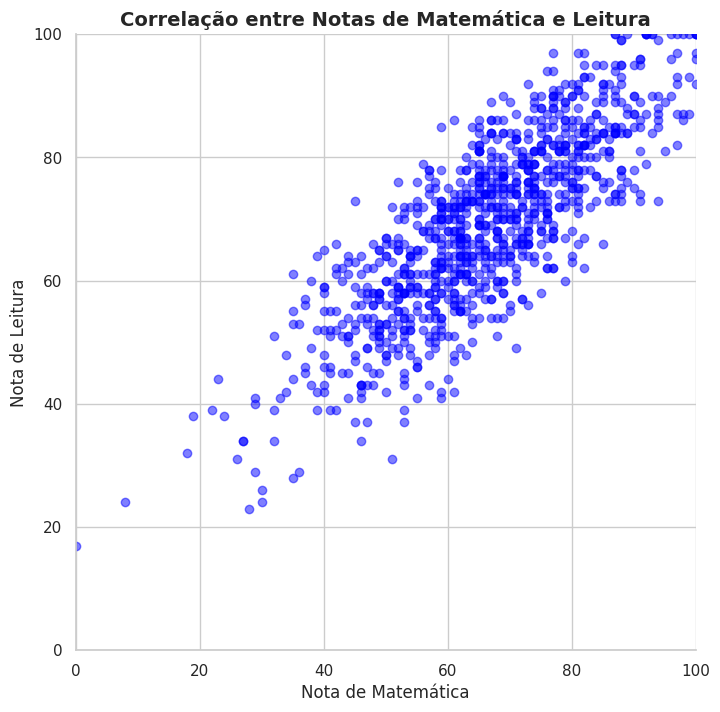

In [19]:
# Dados para o Desafio 2.4
plt.figure(figsize=(8, 8))
plt.scatter(x=df_performance["math_score"], y=df_performance["reading_score"], alpha=0.5, color="blue")
plt.title("Correlação entre Notas de Matemática e Leitura", fontsize=14, fontweight="bold")
plt.xlabel("Nota de Matemática")
plt.ylabel("Nota de Leitura")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.show()

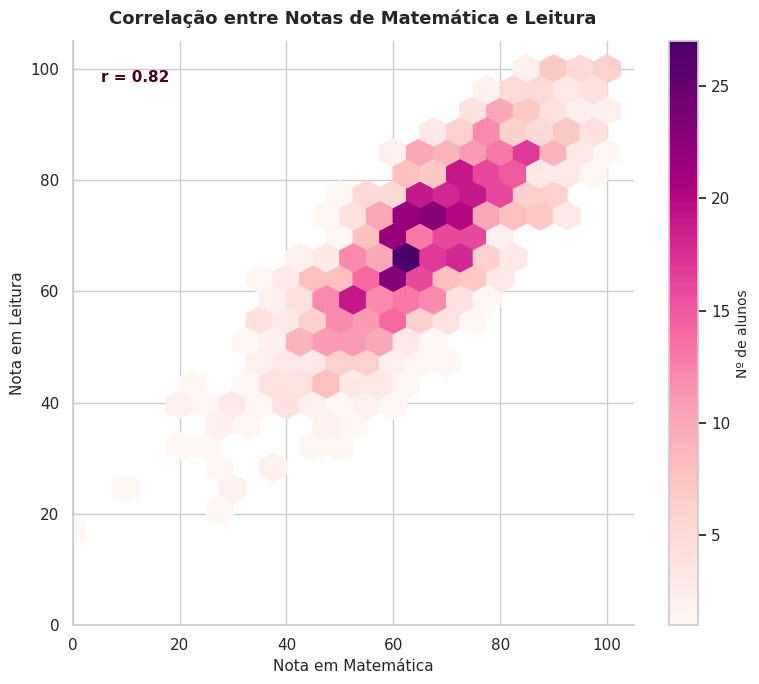

In [22]:
# 1. Problemas identificados:
#  O primeiro problema é o overplotting: com 1000 pontos no mesmo espaço, muitos ficam sobrepostos e o alpha=0.5 não resolve bem, tornando impossível perceber onde a densidade é maior. O segundo é o uso de azul sólido sem gradiente ou codificação de densidade, o que viola a hierarquia de Cleveland-McGill já que a cor poderia estar comunicando informação útil sobre concentração dos dados em vez de ser apenas decorativa. O terceiro é que o gráfico não mostra a distribuição marginal de cada variável individualmente, perdendo contexto importante sobre a forma de cada uma.

# 2. Seu código Python refatorado:
#Em vez de pontos sobrepostos ou curvas de nível, ele divide o espaço em células hexagonais e colore pela densidade real,quanto mais escuro, mais alunos naquela região.
corr = df_performance["math_score"].corr(df_performance["reading_score"])

corr = df_performance["math_score"].corr(df_performance["reading_score"])

fig, ax = plt.subplots(figsize=(8, 7))

hb = ax.hexbin(
    df_performance["math_score"],
    df_performance["reading_score"],
    gridsize=20,
    cmap="RdPu",
    mincnt=1
)

cb = fig.colorbar(hb, ax=ax)
cb.set_label("Nº de alunos", fontsize=10)

ax.text(
    0.05, 0.93,
    f"r = {corr:.2f}",
    transform=ax.transAxes,
    fontsize=11,
    color="#4A0028",
    fontweight="bold"
)

ax.set_xlabel("Nota em Matemática", fontsize=11)
ax.set_ylabel("Nota em Leitura", fontsize=11)
ax.set_xlim(0, 105)
ax.set_ylim(0, 105)
ax.set_title("Correlação entre Notas de Matemática e Leitura",
             fontsize=13, fontweight="bold", pad=12)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Desafio 2.5: Desempenho Geral por Curso de Preparação (Gráfico de Pizza com Múltiplas Variáveis)

Cenário: Um conselheiro estudantil quer visualizar o impacto do curso de preparação (test_preparation_course) no desempenho geral dos alunos, mas o gráfico atual tenta mostrar muitas coisas de uma vez de forma ineficaz.

Sua Tarefa:

1. Quais são os 3 principais problemas de design/estatísticos neste gráfico, especialmente em relação ao uso do gráfico de pizza para comparar médias e à representação de múltiplas variáveis?

2. Modifique o código para criar uma visualização mais eficaz que compare o desempenho médio em cada matéria (não apenas a média geral) entre os alunos que completaram e os que não completaram o curso de preparação.

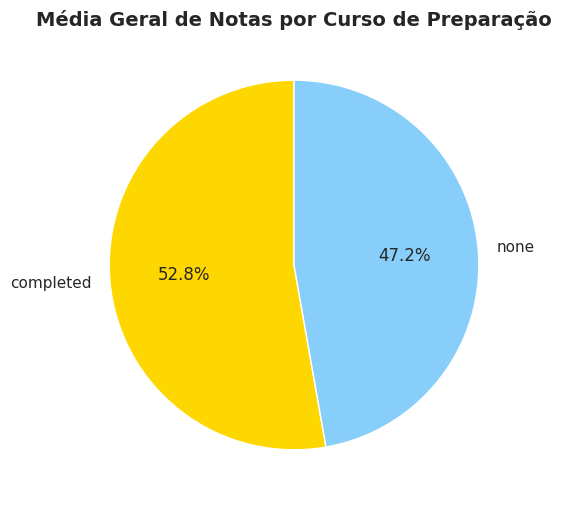

In [23]:
# Dados para o Desafio 2.5
df_prep_course = df_performance.groupby("test_preparation_course")[["math_score", "reading_score", "writing_score"]].mean().mean(axis=1).reset_index(name="overall_average_score")

plt.figure(figsize=(6, 6))
plt.pie(df_prep_course["overall_average_score"], labels=df_prep_course["test_preparation_course"], autopct="%1.1f%%", startangle=90, colors=["gold", "lightskyblue"])
plt.title("Média Geral de Notas por Curso de Preparação", fontsize=14, fontweight="bold")
plt.show()

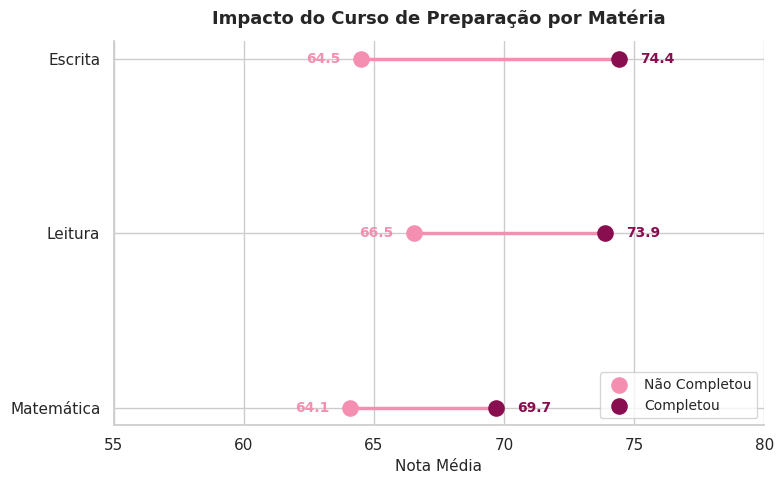

In [24]:
# 1. Problemas identificados:
#  O primeiro problema é o uso de gráfico de pizza pra comparar médias, que é comum. Pizza usa ângulo e área como codificação visual, que estão no final da hierarquia de Cleveland-McGill em termos de precisão perceptiva. Aqui as fatias ficam com tamanhos parecidos e fica impossível julgar a diferença real. O segundo é que agregar as três matérias numa média geral esconde informação importante, não dá pra saber se o curso ajuda mais em matemática, leitura ou escrita. O terceiro é que as cores ouro e azul celeste não têm nenhum significado semântico e ainda dificultam a comparação direta entre os grupos, violando o princípio de semelhança do Gestalt.

# 2. Seu código Python refatorado:
# um dot plot com linhas de conexão seria melhor aqui porque o foco real é a diferença entre os dois grupos em cada matéria, não o valor absoluto das médias. Ele reduz bastante o chartjunk e torna a comparação mais direta.
medias = df_performance.groupby("test_preparation_course")[
    ["math_score", "reading_score", "writing_score"]
].mean().reset_index()

medias_long = medias.melt(
    id_vars="test_preparation_course",
    value_vars=["math_score", "reading_score", "writing_score"],
    var_name="materia",
    value_name="media"
)

medias_long["materia"] = medias_long["materia"].map({
    "math_score": "Matemática",
    "reading_score": "Leitura",
    "writing_score": "Escrita"
})

medias_long["test_preparation_course"] = medias_long["test_preparation_course"].map({
    "completed": "Completou",
    "none": "Não Completou"
})

fig, ax = plt.subplots(figsize=(8, 5))

materias = ["Matemática", "Leitura", "Escrita"]

for materia in materias:
    vals = medias_long[medias_long["materia"] == materia].set_index("test_preparation_course")["media"]
    ax.plot(
        [vals["Não Completou"], vals["Completou"]],
        [materia, materia],
        color="#F48FB1", linewidth=2.5, zorder=1
    )
    ax.scatter(vals["Não Completou"], materia,
               color="#F48FB1", s=120, zorder=2, label="Não Completou" if materia == "Matemática" else "")
    ax.scatter(vals["Completou"], materia,
               color="#880E4F", s=120, zorder=2, label="Completou" if materia == "Matemática" else "")

    ax.text(vals["Não Completou"] - 0.8, materia, f'{vals["Não Completou"]:.1f}',
            ha='right', va='center', fontsize=10, color="#F48FB1", fontweight='bold')
    ax.text(vals["Completou"] + 0.8, materia, f'{vals["Completou"]:.1f}',
            ha='left', va='center', fontsize=10, color="#880E4F", fontweight='bold')

ax.set_xlabel("Nota Média", fontsize=11)
ax.set_ylabel("")
ax.set_title("Impacto do Curso de Preparação por Matéria",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=10, loc="lower right")
ax.set_xlim(55, 80)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()